# 04. Synthetic Control

Synthetic control is a quasi-experimental design for settings with one treated aggregate unit, a clear intervention date, and a pool of untreated donor units. Instead of choosing one control unit by hand, we construct a weighted average of donor units that closely matches the treated unit before the intervention.

The method is especially useful when the treated unit is unique: one state, one city, one country, one enterprise customer, one marketplace, one warehouse network, one product line, or one large region. The core question is: can a weighted combination of untreated units reproduce the treated unit's pre-intervention trajectory well enough to be a credible post-intervention counterfactual?


## Learning Goals

By the end of this notebook, you should be able to:

- Explain why synthetic control is useful for one treated aggregate unit.
- Construct donor weights that are nonnegative and sum to one.
- Estimate treatment effects as treated outcome minus synthetic outcome.
- Diagnose pre-treatment fit with path plots, gaps, and RMSPE/RMSE.
- Interpret donor weights and donor-pool composition.
- Run placebo-in-space tests by pretending each donor unit was treated.
- Use leave-one-out sensitivity checks for high-weight donors.
- Recognize when synthetic control is not credible because the treated unit cannot be matched before treatment.
- Translate a synthetic-control analysis into an industry decision readout.


## Mathematical Setup: Synthetic Control Weights

Synthetic control constructs a weighted combination of untreated donor units to approximate the treated unit before intervention. Let $Y_{1t}$ be the treated unit outcome and $Y_{jt}$ be donor unit outcomes. Choose donor weights $w_j$ that are nonnegative and sum to one:

$$
w_j \ge 0, \qquad \sum_{j=2}^{J+1}w_j = 1
$$

The pre-intervention fitting problem is:

$$
\min_w \sum_{t<T_0}\left(Y_{1t} - \sum_{j=2}^{J+1}w_jY_{jt}\right)^2
$$

The post-intervention treatment effect estimate at time $t$ is:

$$
\widehat{\tau}_t = Y_{1t} - \sum_{j=2}^{J+1}\widehat{w}_jY_{jt}
$$

The design is credible only if the weighted donor series tracks the treated unit well before the intervention. Poor pre-fit means the post-period gap may reflect mismatch rather than a causal effect.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def rmse(values):
    """Compute root mean squared error for synthetic-control fit diagnostics.

    Args:
        values: Numeric values to summarize.

    Returns:
        float: Root mean squared error.
    """
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2)))


def summarize_path(path_frame, intervention_month):
    """Summarize pre-fit, post-fit, effect size, and RMSPE ratio for a synthetic-control path.

    Args:
        path_frame: Synthetic-control path table with treated, synthetic, and gap columns.
        intervention_month: Time index at which the intervention begins.

    Returns:
        pandas.Series: Synthetic-control fit and gap diagnostics.
    """
    pre = path_frame["month"] < intervention_month
    post = ~pre
    return pd.Series(
        {
            "pre_RMSE": rmse(path_frame.loc[pre, "gap"]),
            "post_RMSE": rmse(path_frame.loc[post, "gap"]),
            "post_to_pre_RMSE_ratio": rmse(path_frame.loc[post, "gap"]) / rmse(path_frame.loc[pre, "gap"]),
            "average_post_gap": path_frame.loc[post, "gap"].mean(),
        }
    )

## 1. Where Synthetic Control Fits

Difference-in-differences needs a comparison group whose untreated trend represents the treated group's untreated trend. Synthetic control builds that comparison group explicitly. It chooses donor weights so the synthetic unit tracks the treated unit before the intervention.

The canonical examples are policy case studies: the Basque Country conflict study (Abadie & Gardeazabal, 2003) and California's tobacco-control program (Abadie, Diamond, & Hainmueller, 2010). The same design appears in industry when a major change affects one unit first:

- A flagship market launches a new pricing policy.
- One fulfillment region receives a routing algorithm.
- One enterprise customer receives a premium support workflow.
- One country gets regulatory approval for a product feature.
- One warehouse network gets a labor-scheduling intervention.

Synthetic control is not magic. Its credibility comes from design transparency: the donor pool, weights, pre-treatment fit, and placebo checks are all visible.


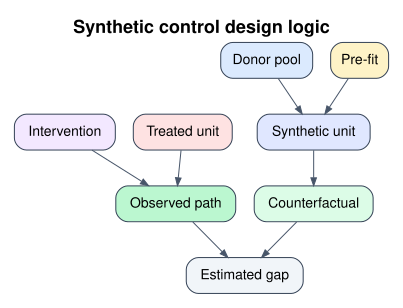

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("Donor pool", "Synthetic unit"),
        ("Pre-fit", "Synthetic unit"),
        ("Synthetic unit", "Counterfactual"),
        ("Treated unit", "Observed path"),
        ("Intervention", "Observed path"),
        ("Counterfactual", "Estimated gap"),
        ("Observed path", "Estimated gap"),
    ],
    title="Synthetic control design logic",
    node_colors={
        "Donor pool": "#dbeafe",
        "Synthetic unit": "#e0e7ff",
        "Pre-fit": "#fef3c7",
        "Counterfactual": "#dcfce7",
        "Treated unit": "#fee2e2",
        "Observed path": "#bbf7d0",
        "Intervention": "#f3e8ff",
        "Estimated gap": "#f1f5f9",
    },
    rankdir="TB",
)

The treated unit has an observed post-intervention path, but its untreated post-intervention path is missing. Synthetic control fills that missing path using a weighted donor combination chosen before looking at post-treatment outcomes.


## 2. The Optimization Problem

Let $Y_{1t}$ be the treated unit outcome and $Y_{jt}$ be donor unit $j$'s outcome. We choose weights $w_j$ to match the treated unit before treatment:

$$
\hat{W} = \arg\min_W \sum_{t < T_0}\left(Y_{1t} - \sum_{j=1}^{J} w_j Y_{jt}\right)^2
$$

subject to:

$$
w_j \ge 0 \quad \text{and} \quad \sum_{j=1}^{J} w_j = 1
$$

The synthetic counterfactual after treatment is:

$$
\hat{Y}_{1t}(0) = \sum_{j=1}^{J} \hat{w}_j Y_{jt}
$$

and the estimated treatment effect is:

$$
\hat{\tau}_t = Y_{1t} - \hat{Y}_{1t}(0)
$$

Abadie, Diamond, and Hainmueller (2011) emphasize that synthetic control makes the comparison transparent: the selected donors, their weights, and the quality of the pre-treatment match are all inspectable.


## 3. Running Example: One Market Launches a Premium Support Policy

Suppose one flagship market launches a premium AI-assisted support policy at month 30. The outcome is monthly net revenue per account. Other markets do not launch the policy during the observation window.

We will simulate 20 donor markets. The treated market's untreated path is close to a convex combination of a few donors, which is exactly the setting where synthetic control should work well.


**Dataset and experiment setup.** The synthetic-control dataset represents one treated market and a donor pool of untreated markets observed over time. The outcome is monthly net revenue per account. The treated market is generated as a weighted combination of several donors before intervention, plus noise and a known post-launch policy effect. This is the setting where synthetic control is meant to work: the treated unit is unique, no single donor is a perfect control, but a transparent weighted donor mix can reproduce the pre-intervention path. The known weights and effect are used only to validate the teaching example.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_synthetic_control_data(n_donors=20, months=range(48), intervention_month=30, seed=4404):
    """Generate a treated unit and donor pool for synthetic-control teaching.

    Args:
        n_donors: Number of untreated donor units in the synthetic-control simulation.
        months: Sequence of time periods used in the panel or time-series simulation.
        intervention_month: Time index at which the intervention begins.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)
    months = np.array(list(months))

    macro = 0.18 * months + 2.2 * np.sin(months / 4.0) + 1.0 * np.cos(months / 9.0)
    seasonal = np.sin(2 * np.pi * months / 12)

    donor_rows = []
    for donor_id in range(n_donors):
        intercept = rng.normal(80, 7)
        trend = rng.normal(0.35, 0.08)
        macro_loading = rng.normal(1.0, 0.18)
        season_loading = rng.normal(1.8, 0.5)
        curvature = rng.normal(0, 0.002)
        eps_prev = rng.normal(0, 1.0)

        for month in months:
            eps = 0.55 * eps_prev + rng.normal(0, 1.0)
            eps_prev = eps
            outcome = (
                intercept
                + trend * month
                + macro_loading * macro[month]
                + season_loading * seasonal[month]
                + curvature * (month - 24) ** 2
                + eps
            )
            donor_rows.append(
                {
                    "unit": f"Donor {donor_id + 1:02d}",
                    "month": int(month),
                    "outcome": outcome,
                    "treated_unit": 0,
                    "post": int(month >= intervention_month),
                    "true_effect": 0.0,
                    "untreated_outcome": outcome,
                }
            )

    donor_df = pd.DataFrame(donor_rows)
    donor_matrix = donor_df.pivot(index="month", columns="unit", values="outcome").sort_index()

    true_weights = np.zeros(n_donors)
    true_weights[[2, 6, 13, 17]] = [0.36, 0.27, 0.22, 0.15]
    untreated_treated = donor_matrix.to_numpy() @ true_weights

    idiosyncratic = []
    eps_prev = rng.normal(0, 0.4)
    for _ in months:
        eps_prev = 0.50 * eps_prev + rng.normal(0, 0.3)
        idiosyncratic.append(eps_prev)
    untreated_treated = untreated_treated + np.array(idiosyncratic)

    treatment_effect = np.where(months >= intervention_month, 2.0 + 0.55 * (months - intervention_month), 0.0)
    treatment_effect = np.minimum(treatment_effect, 9.0)
    observed_treated = untreated_treated + treatment_effect

    treated_df = pd.DataFrame(
        {
            "unit": "Treated Market",
            "month": months.astype(int),
            "outcome": observed_treated,
            "treated_unit": 1,
            "post": (months >= intervention_month).astype(int),
            "true_effect": treatment_effect,
            "untreated_outcome": untreated_treated,
        }
    )

    frame = pd.concat([donor_df, treated_df], ignore_index=True)
    true_weight_table = pd.DataFrame(
        {
            "unit": [f"Donor {idx + 1:02d}" for idx in range(n_donors)],
            "true_data_generating_weight": true_weights,
        }
    )
    return frame, true_weight_table


intervention_month = 30
df, true_weight_table = simulate_synthetic_control_data(intervention_month=intervention_month)

data_summary = pd.Series(
    {
        "units": df["unit"].nunique(),
        "donor_units": df["unit"].nunique() - 1,
        "months": df["month"].nunique(),
        "intervention_month": intervention_month,
        "post_months": df.loc[df["post"].eq(1), "month"].nunique(),
        "true_average_post_effect": df.loc[df["unit"].eq("Treated Market") & df["post"].eq(1), "true_effect"].mean(),
    }
).to_frame("value")
smart_display(data_summary)

,value
units,21.000
donor_units,20.000
months,48.000
intervention_month,30.000
post_months,18.000
true_average_post_effect,6.328


In Running Example: One Market Launches a Premium Support Policy, the table checks pre-intervention fit before any post-period gap is interpreted. The donor-weighted series has to earn trust before the launch date.

In real data we would not know the true weights or true effect. We include them only to make the mechanics testable.


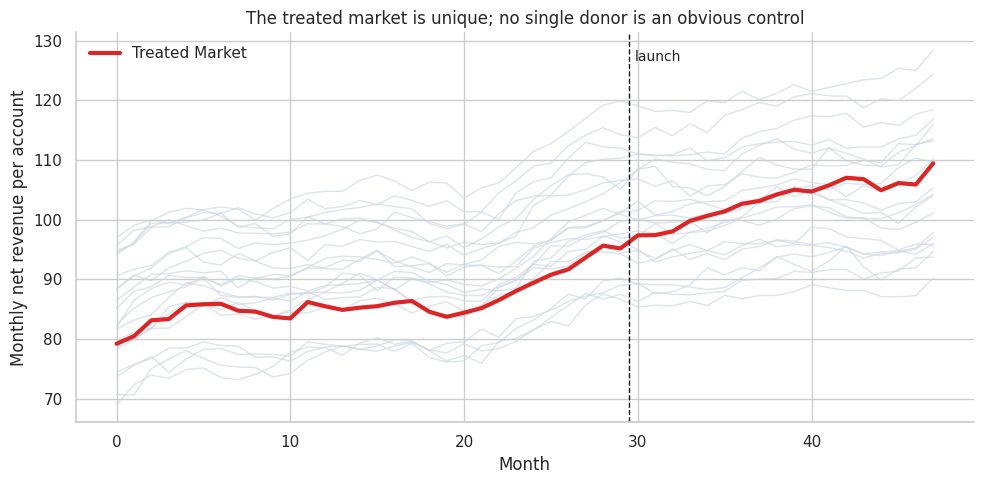

In [5]:
# Build the Running Example: One Market Launches a Premium Support Policy plot from the quantities computed above.
wide = df.pivot(index="month", columns="unit", values="outcome").sort_index()

fig, ax = plt.subplots(figsize=(10, 5.0))
for unit in wide.columns:
    if unit == "Treated Market":
        ax.plot(wide.index, wide[unit], color="#dc2626", linewidth=3, label="Treated Market")
    else:
        ax.plot(wide.index, wide[unit], color="#cbd5e1", linewidth=1, alpha=0.65)
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.text(intervention_month - 0.2, wide.max().max(), "launch", ha="left", va="top", fontsize=10)
ax.set_title("The treated market is unique; no single donor is an obvious control")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The treated market sits among the donors but does not obviously equal any single donor. Synthetic control asks whether a weighted donor combination can match the treated path before month 30.


## 4. Fit the Synthetic Control

We will fit weights using only months before the intervention. The optimizer knows nothing about post-intervention outcomes.


In [6]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def fit_synthetic_control(frame, treated_unit, donor_units=None, intervention_month=30, fit_months=None):
    """Fit nonnegative donor weights that sum to one using pre-intervention outcomes.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        treated_unit: Focal treated unit in the synthetic-control analysis.
        donor_units: Untreated donor units available for synthetic-control weighting.
        intervention_month: Time index at which the intervention begins.
        fit_months: Pre-intervention time periods used to fit donor weights.

    Returns:
        tuple: Donor-weight table, treated-versus-synthetic path, and optimizer result.
    """
    wide = frame.pivot(index="month", columns="unit", values="outcome").sort_index()
    if donor_units is None:
        donor_units = [unit for unit in wide.columns if unit != treated_unit]
    if fit_months is None:
        fit_months = [month for month in wide.index if month < intervention_month]

    X0 = wide.loc[fit_months, donor_units].to_numpy()
    x1 = wide.loc[fit_months, treated_unit].to_numpy()
    n_donors = len(donor_units)
    initial_weights = np.repeat(1 / n_donors, n_donors)

    def objective(weights):
        """Compute pre-intervention mean squared error for candidate synthetic-control weights.

        Args:
            weights: Observation weights used to define the target pseudo-population or summary.

        Returns:
            float: Mean squared pre-intervention fit error.
        """
        return np.mean((x1 - X0 @ weights) ** 2)

    constraints = {"type": "eq", "fun": lambda weights: weights.sum() - 1}
    bounds = [(0.0, 1.0)] * n_donors
    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000},
    )

    weights = result.x
    synthetic_path = wide[donor_units].to_numpy() @ weights
    path = pd.DataFrame(
        {
            "month": wide.index,
            "treated": wide[treated_unit].to_numpy(),
            "synthetic": synthetic_path,
        }
    )
    path["gap"] = path["treated"] - path["synthetic"]

    weight_table = pd.DataFrame({"unit": donor_units, "weight": weights}).sort_values("weight", ascending=False)
    return weight_table, path, result


donor_units = [unit for unit in wide.columns if unit != "Treated Market"]
weight_table, synth_path, optimizer_result = fit_synthetic_control(
    df,
    treated_unit="Treated Market",
    donor_units=donor_units,
    intervention_month=intervention_month,
)

pd.Series(
    {
        "optimizer_success": optimizer_result.success,
        "optimizer_objective_pre_MSE": optimizer_result.fun,
        "sum_of_weights": weight_table["weight"].sum(),
        "nonzero_weight_count": (weight_table["weight"] > 0.01).sum(),
    }
).to_frame("value")

,value
optimizer_success,True
optimizer_objective_pre_MSE,0.108
sum_of_weights,1.000
nonzero_weight_count,7


In Fit the Synthetic Control, the table is also evidence about the trend assumption. Pre-period behavior is what makes the untreated counterfactual believable.

In [7]:
weight_display = (
    weight_table.merge(true_weight_table, on="unit", how="left")
    .assign(weight=lambda x: x["weight"].where(x["weight"].abs() > 1e-6, 0.0))
)
weight_display.head(10)


,unit,weight,true_data_generating_weight
0,Donor 03,0.249,0.360
1,Donor 14,0.222,0.220
2,Donor 07,0.198,0.270
3,Donor 18,0.183,0.150
4,Donor 02,0.083,0.000
5,Donor 10,0.043,0.000
6,Donor 04,0.022,0.000
7,Donor 08,0.000,0.000
8,Donor 11,0.000,0.000
9,Donor 01,0.000,0.000


In Fit the Synthetic Control, the table checks pre-intervention fit before any post-period gap is interpreted. Good pre-intervention fit is what makes the post-launch gap interpretable.

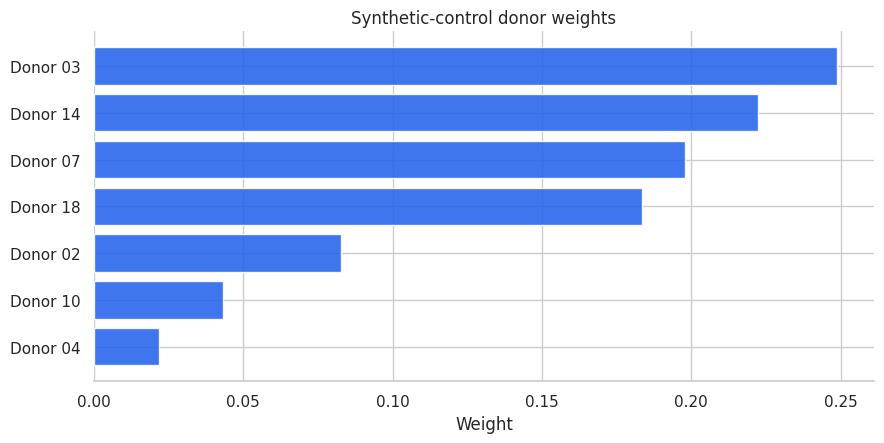

In [8]:
# Build the Fit the Synthetic Control plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.6))
plot_weights = weight_display[weight_display["weight"] > 0.005].sort_values("weight")
ax.barh(plot_weights["unit"], plot_weights["weight"], color="#2563eb", alpha=0.88)
ax.set_title("Synthetic-control donor weights")
ax.set_xlabel("Weight")
ax.set_ylabel("")
sns.despine(ax=ax, left=True)
plt.tight_layout()


The weights are sparse: only a few donors contribute meaningfully. This is one reason synthetic control is easy to explain to nontechnical stakeholders. We can say which markets are forming the counterfactual and how much each contributes.


## 5. Path Plot and Gap Plot

The first diagnostic is the path plot: treated outcome versus synthetic outcome. The second is the gap plot: treated minus synthetic. A credible synthetic control should have small pre-treatment gaps.


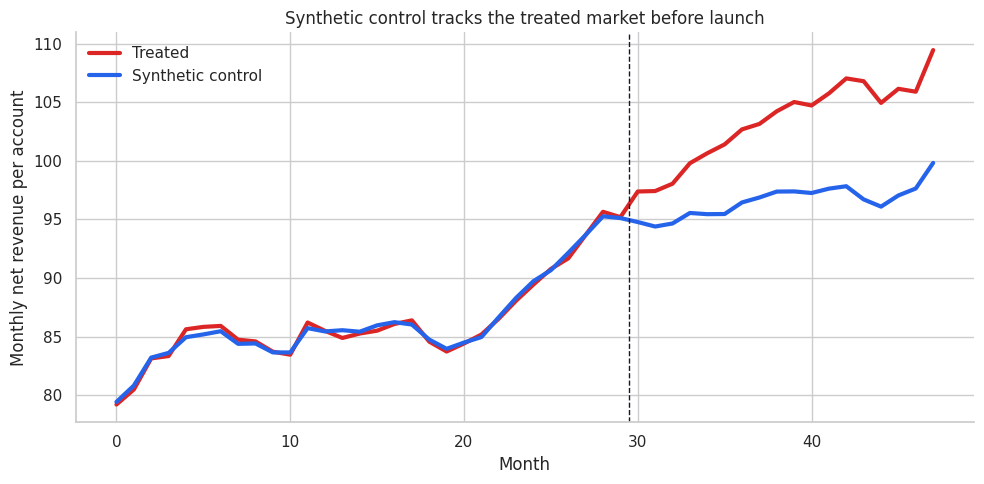

In [9]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def plot_synthetic_path(path_frame, intervention_month, title):
    """Plot the treated path against the fitted synthetic-control path.

    Args:
        path_frame: Synthetic-control path table with treated, synthetic, and gap columns.
        intervention_month: Time index at which the intervention begins.
        title: Title shown on the resulting figure.

    Returns:
        tuple: Matplotlib figure and axes for treated versus synthetic paths.
    """
    fig, ax = plt.subplots(figsize=(10, 5.0))
    ax.plot(path_frame["month"], path_frame["treated"], color="#dc2626", linewidth=3, label="Treated")
    ax.plot(path_frame["month"], path_frame["synthetic"], color="#2563eb", linewidth=3, label="Synthetic control")
    ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly net revenue per account")
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax


def plot_gap(path_frame, intervention_month, title):
    """Plot treated minus synthetic outcomes over time.

    Args:
        path_frame: Synthetic-control path table with treated, synthetic, and gap columns.
        intervention_month: Time index at which the intervention begins.
        title: Title shown on the resulting figure.

    Returns:
        tuple: Matplotlib figure and axes for the synthetic-control gap path.
    """
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(path_frame["month"], path_frame["gap"], color="#7c3aed", linewidth=2.5)
    ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
    ax.axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Treated minus synthetic")
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax


plot_synthetic_path(synth_path, intervention_month, "Synthetic control tracks the treated market before launch");

In Path Plot and Gap Plot, the figure checks pre-intervention fit before any post-period gap is interpreted. A synthetic control is only as convincing as its pre-launch match.

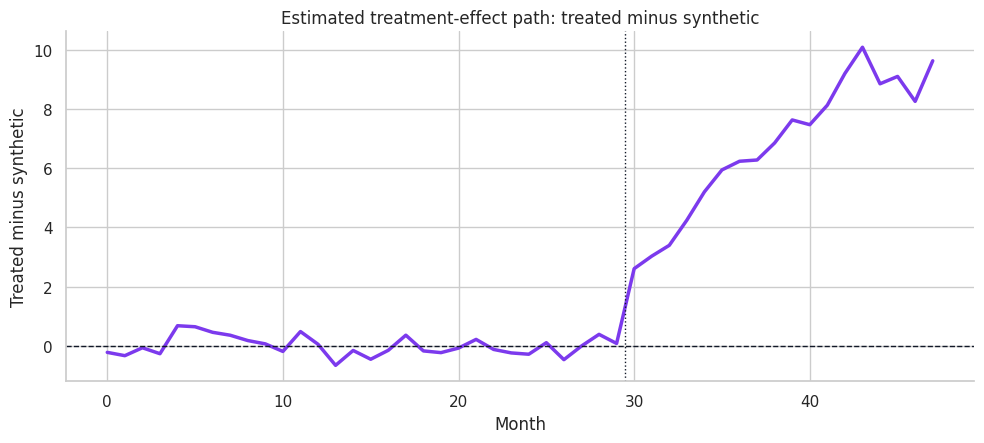

In [10]:
plot_gap(synth_path, intervention_month, "Estimated treatment-effect path: treated minus synthetic");


In Path Plot and Gap Plot, the figure checks pre-intervention fit before any post-period gap is interpreted. Before looking at the gap, check whether the donors reproduce the treated path.

In [11]:
fit_summary = summarize_path(synth_path, intervention_month).to_frame("synthetic_control")
true_average_post_effect = df.loc[df["unit"].eq("Treated Market") & df["post"].eq(1), "true_effect"].mean()
fit_summary.loc["true_average_post_effect", "synthetic_control"] = true_average_post_effect
fit_summary.loc["bias_in_average_post_gap", "synthetic_control"] = (
    fit_summary.loc["average_post_gap", "synthetic_control"] - true_average_post_effect
)
smart_display(fit_summary)


,synthetic_control
pre_RMSE,0.329
post_RMSE,7.156
post_to_pre_RMSE_ratio,21.748
average_post_gap,6.786
true_average_post_effect,6.328
bias_in_average_post_gap,0.458


The pre-treatment fit is strong: the synthetic unit tracks the treated unit closely before launch. After launch, the treated market rises above the synthetic control. In a real project, the post-launch gap is the estimated effect path.

The single average post gap is useful, but the time path matters too. A premium support policy may take time to affect renewals, upsells, or customer health; the gap plot shows that dynamic story.


## 6. Compare Against Simpler Controls

Synthetic control should beat naive alternatives in pre-treatment fit. We compare it with:

- A simple average of all donor markets.
- The single donor with the best pre-treatment fit.

If synthetic control does not improve pre-treatment fit over these simple baselines, the added complexity may not be worthwhile.


In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simple_control_paths(frame, treated_unit, donor_units, intervention_month):
    """Build average-donor and best-single-donor comparison paths.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        treated_unit: Focal treated unit in the synthetic-control analysis.
        donor_units: Untreated donor units available for synthetic-control weighting.
        intervention_month: Time index at which the intervention begins.

    Returns:
        pandas.DataFrame: Treated path with average-donor and best-donor controls.
    """
    wide = frame.pivot(index="month", columns="unit", values="outcome").sort_index()
    treated = wide[treated_unit]
    donor_average = wide[donor_units].mean(axis=1)

    pre_months = wide.index < intervention_month
    donor_pre_rmse = {
        donor: rmse(treated.loc[pre_months] - wide.loc[pre_months, donor])
        for donor in donor_units
    }
    best_donor = min(donor_pre_rmse, key=donor_pre_rmse.get)

    output = pd.DataFrame(
        {
            "month": wide.index,
            "treated": treated.to_numpy(),
            "donor_average": donor_average.to_numpy(),
            "best_single_donor": wide[best_donor].to_numpy(),
        }
    )
    output["gap_donor_average"] = output["treated"] - output["donor_average"]
    output["gap_best_single_donor"] = output["treated"] - output["best_single_donor"]
    return output, best_donor


simple_paths, best_donor = simple_control_paths(df, "Treated Market", donor_units, intervention_month)
comparison_metrics = pd.DataFrame(
    {
        "method": ["Synthetic control", "Average donor", f"Best single donor ({best_donor})"],
        "pre_RMSE": [
            rmse(synth_path.loc[synth_path["month"] < intervention_month, "gap"]),
            rmse(simple_paths.loc[simple_paths["month"] < intervention_month, "gap_donor_average"]),
            rmse(simple_paths.loc[simple_paths["month"] < intervention_month, "gap_best_single_donor"]),
        ],
        "average_post_gap": [
            synth_path.loc[synth_path["month"] >= intervention_month, "gap"].mean(),
            simple_paths.loc[simple_paths["month"] >= intervention_month, "gap_donor_average"].mean(),
            simple_paths.loc[simple_paths["month"] >= intervention_month, "gap_best_single_donor"].mean(),
        ],
    }
)
smart_display(comparison_metrics)

,method,pre_RMSE,average_post_gap
0,Synthetic control,0.329,6.786
1,Average donor,5.407,0.556
2,Best single donor (Donor 01),1.170,8.416


In Compare Against Simpler Controls, the table checks pre-intervention fit before any post-period gap is interpreted. The donor-weighted series has to earn trust before the launch date.

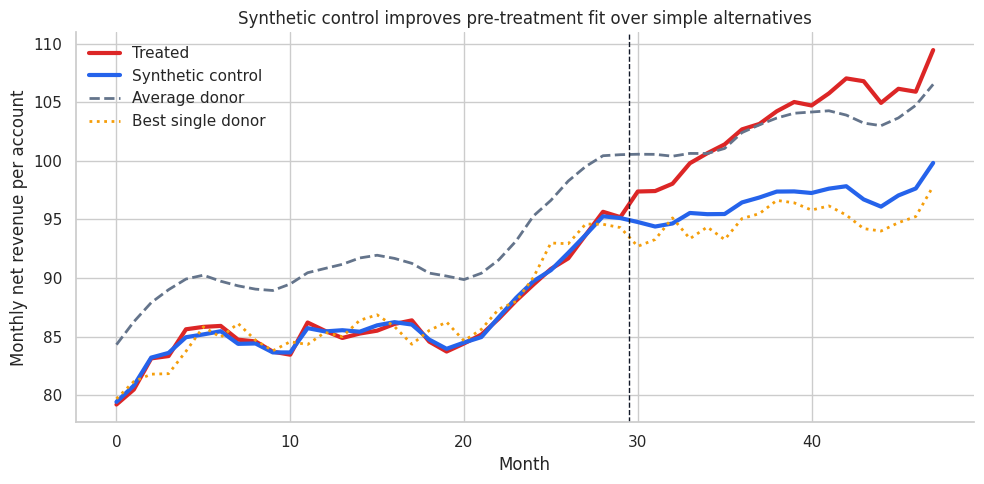

In [13]:
# Build the Compare Against Simpler Controls plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
ax.plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Synthetic control")
ax.plot(simple_paths["month"], simple_paths["donor_average"], color="#64748b", linewidth=2, linestyle="--", label="Average donor")
ax.plot(simple_paths["month"], simple_paths["best_single_donor"], color="#f59e0b", linewidth=2, linestyle=":", label="Best single donor")
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Synthetic control improves pre-treatment fit over simple alternatives")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The average donor is too blunt, and the best single donor is still not as close as the weighted combination. Synthetic control earns its keep by improving the pre-treatment match.


## 7. Placebo-in-Space Tests

Classical synthetic-control inference often uses placebo tests. We pretend each donor was treated at the same intervention date, rebuild a synthetic control from the remaining donors, and compare the donor placebo gaps with the treated-unit gap.

If the treated unit's post/pre RMSPE ratio is unusually large relative to placebo ratios, the observed effect is less likely to be ordinary donor-pool noise.

Abadie, Diamond, and Hainmueller (2011) describe these placebo checks as permutation-style inference: the same procedure is applied to units that did not receive the intervention.


In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def run_placebo_tests(frame, donor_units, intervention_month):
    """Run placebo-in-space synthetic-control fits for each donor unit.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        donor_units: Untreated donor units available for synthetic-control weighting.
        intervention_month: Time index at which the intervention begins.

    Returns:
        tuple: Placebo metric table and stacked placebo paths.
    """
    placebo_rows = []
    placebo_paths = []

    for placebo_unit in donor_units:
        pool = [unit for unit in donor_units if unit != placebo_unit]
        _, path, result = fit_synthetic_control(
            frame,
            treated_unit=placebo_unit,
            donor_units=pool,
            intervention_month=intervention_month,
        )
        path = path.copy()
        path["placebo_unit"] = placebo_unit
        placebo_paths.append(path)

        metrics = summarize_path(path, intervention_month)
        placebo_rows.append(
            {
                "placebo_unit": placebo_unit,
                "optimizer_success": result.success,
                **metrics.to_dict(),
            }
        )

    return pd.DataFrame(placebo_rows), pd.concat(placebo_paths, ignore_index=True)


placebo_table, placebo_paths = run_placebo_tests(df, donor_units, intervention_month)
treated_metrics = summarize_path(synth_path, intervention_month)
treated_ratio = treated_metrics["post_to_pre_RMSE_ratio"]
placebo_p_value = (1 + (placebo_table["post_to_pre_RMSE_ratio"] >= treated_ratio).sum()) / (1 + len(placebo_table))

pd.Series(
    {
        "treated_post_to_pre_RMSE_ratio": treated_ratio,
        "placebo_units": len(placebo_table),
        "randomization_style_p_value": placebo_p_value,
    }
).to_frame("value")

,value
treated_post_to_pre_RMSE_ratio,21.748
placebo_units,20.000
randomization_style_p_value,0.048


In Placebo-in-Space Tests, the table checks pre-intervention fit before any post-period gap is interpreted. Good pre-intervention fit is what makes the post-launch gap interpretable.

In [15]:
placebo_table.sort_values("post_to_pre_RMSE_ratio", ascending=False).head(10)


,placebo_unit,optimizer_success,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
0,Donor 01,True,0.825,3.101,3.760,-2.878
8,Donor 09,True,0.750,2.771,3.693,-2.475
13,Donor 14,True,1.525,4.126,2.706,-3.845
10,Donor 11,True,0.804,2.176,2.705,1.466
4,Donor 05,True,1.161,3.042,2.619,-2.637
19,Donor 20,True,0.781,2.046,2.618,1.823
17,Donor 18,True,1.179,2.635,2.236,-2.133
16,Donor 17,True,0.806,1.781,2.210,1.150
18,Donor 19,True,0.924,1.902,2.059,-1.097
7,Donor 08,True,1.852,3.667,1.979,3.215


In Placebo-in-Space Tests, the table compares the observed series with a counterfactual time path. Seasonality, coincident shocks, and autocorrelation can make a before-after change look more causal than it is.

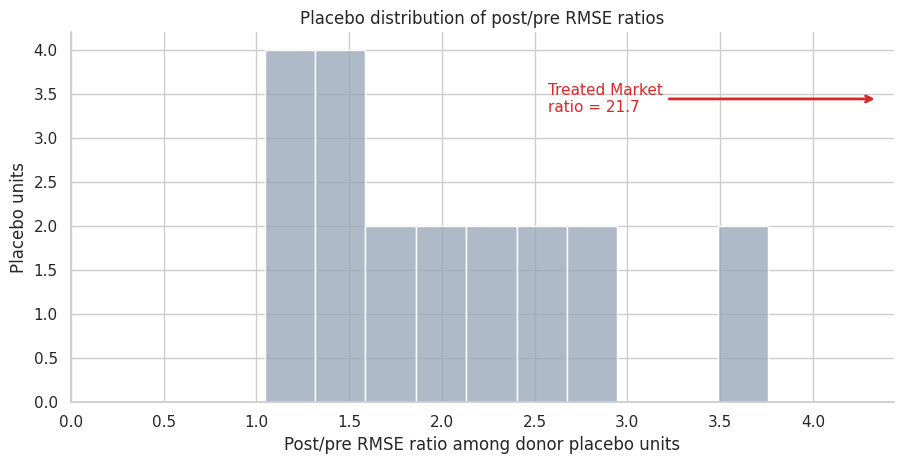

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(9.2, 4.8))
placebo_ratios = placebo_table["post_to_pre_RMSE_ratio"]
sns.histplot(placebo_ratios, bins=10, color="#94a3b8", edgecolor="white", ax=ax)
placebo_max = placebo_ratios.max()
plot_limit = placebo_max * 1.18
ax.set_xlim(0, plot_limit)
annotation_text = f"Treated Market\nratio = {treated_ratio:.1f}"
ax.annotate(
    annotation_text,
    xy=(plot_limit * 0.98, ax.get_ylim()[1] * 0.82),
    xytext=(plot_limit * 0.58, ax.get_ylim()[1] * 0.82),
    arrowprops={"arrowstyle": "->", "color": "#dc2626", "lw": 2},
    ha="left",
    va="center",
    color="#dc2626",
    fontsize=11,
)
ax.set_title("Placebo distribution of post/pre RMSE ratios")
ax.set_xlabel("Post/pre RMSE ratio among donor placebo units")
ax.set_ylabel("Placebo units")
sns.despine(ax=ax)
plt.tight_layout()

In Placebo-in-Space Tests, the figure checks pre-intervention fit before any post-period gap is interpreted. A synthetic control is only as convincing as its pre-launch match.

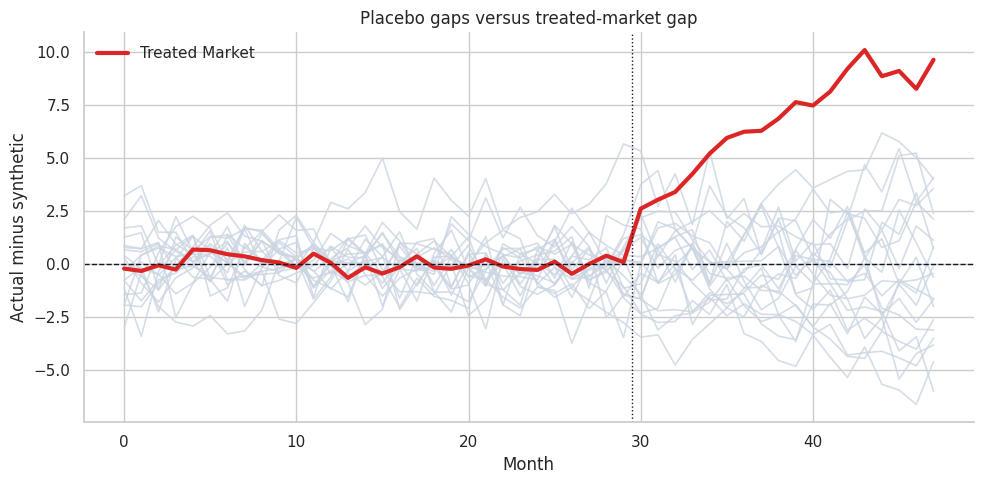

In [17]:
# Build the Placebo-in-Space Tests plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 5.0))
for placebo_unit, group in placebo_paths.groupby("placebo_unit", observed=True):
    ax.plot(group["month"], group["gap"], color="#cbd5e1", linewidth=1.2, alpha=0.8)
ax.plot(synth_path["month"], synth_path["gap"], color="#dc2626", linewidth=3, label="Treated Market")
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Placebo gaps versus treated-market gap")
ax.set_xlabel("Month")
ax.set_ylabel("Actual minus synthetic")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The treated-market gap is much more unusual after launch than the donor placebo gaps. The randomization-style p-value is not a classical large-sample p-value; it is a design-based comparison against the donor pool. With only 20 donors, the smallest possible value is $1/(20+1)$.


## 8. Leave-One-Out Sensitivity

A synthetic control can depend heavily on one donor. Leave-one-out checks remove each important donor and refit the synthetic control. If the conclusion disappears when one donor is removed, the analysis is fragile.


In [18]:
# Build the summary table used to connect the calculation back to the design question.
active_donors = weight_table.loc[weight_table["weight"] > 0.03, "unit"].tolist()
loo_rows = []
loo_paths = []

for removed_donor in active_donors:
    restricted_pool = [unit for unit in donor_units if unit != removed_donor]
    _, loo_path, _ = fit_synthetic_control(
        df,
        treated_unit="Treated Market",
        donor_units=restricted_pool,
        intervention_month=intervention_month,
    )
    loo_path = loo_path.copy()
    loo_path["removed_donor"] = removed_donor
    loo_paths.append(loo_path)
    metrics = summarize_path(loo_path, intervention_month)
    loo_rows.append({"removed_donor": removed_donor, **metrics.to_dict()})

loo_table = pd.DataFrame(loo_rows).sort_values("average_post_gap")
smart_display(loo_table)


,removed_donor,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
3,Donor 18,0.412,6.485,15.740,6.172
1,Donor 14,0.456,6.738,14.786,6.394
2,Donor 07,0.412,6.702,16.256,6.408
5,Donor 10,0.332,7.160,21.543,6.785
4,Donor 02,0.348,7.282,20.923,6.886
0,Donor 03,0.463,7.568,16.355,7.199


In Leave-One-Out Sensitivity, the table checks pre-intervention fit before any post-period gap is interpreted. Before looking at the gap, check whether the donors reproduce the treated path.

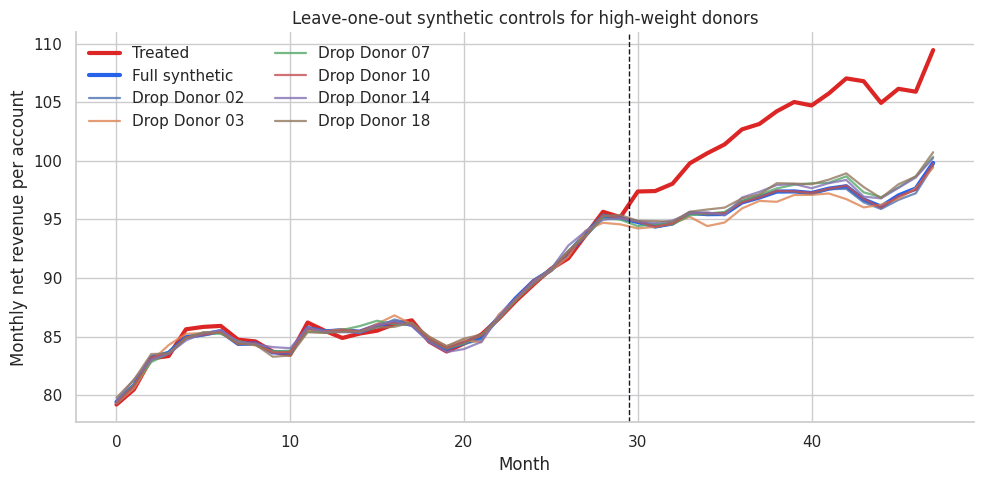

In [19]:
# Build the Leave-One-Out Sensitivity plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 5.0))
ax.plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
ax.plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Full synthetic")
for removed_donor, group in pd.concat(loo_paths).groupby("removed_donor", observed=True):
    ax.plot(group["month"], group["synthetic"], linewidth=1.6, alpha=0.8, label=f"Drop {removed_donor}")
ax.axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Leave-one-out synthetic controls for high-weight donors")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly net revenue per account")
ax.legend(frameon=False, ncol=2)
sns.despine(ax=ax)
plt.tight_layout()


The leave-one-out paths remain below the treated market after launch. That supports the conclusion that the result is not driven by a single donor. The pre-fit may worsen a bit when an important donor is removed, which is expected.


## 9. What Bad Pre-Fit Looks Like

Synthetic control is credible only if the donor pool can reproduce the treated unit before treatment. A poor pre-treatment fit means the synthetic unit is already a bad counterfactual before the intervention.

To see this, remove the donors that actually form the treated market's best pre-treatment match.


In [20]:
# Assemble the What Bad Pre-Fit Looks Like summary table used for interpretation.
top_true_donors = true_weight_table.loc[true_weight_table["true_data_generating_weight"] > 0, "unit"].tolist()
restricted_donor_pool = [unit for unit in donor_units if unit not in top_true_donors]
restricted_weights, restricted_path, _ = fit_synthetic_control(
    df,
    treated_unit="Treated Market",
    donor_units=restricted_donor_pool,
    intervention_month=intervention_month,
)

restricted_summary = pd.DataFrame(
    {
        "Full donor pool": summarize_path(synth_path, intervention_month),
        "Restricted donor pool": summarize_path(restricted_path, intervention_month),
    }
).T
smart_display(restricted_summary)


,pre_RMSE,post_RMSE,post_to_pre_RMSE_ratio,average_post_gap
Full donor pool,0.329,7.156,21.748,6.786
Restricted donor pool,0.622,5.607,9.019,5.373


In What Bad Pre-Fit Looks Like, the table checks pre-intervention fit before any post-period gap is interpreted. The donor-weighted series has to earn trust before the launch date.

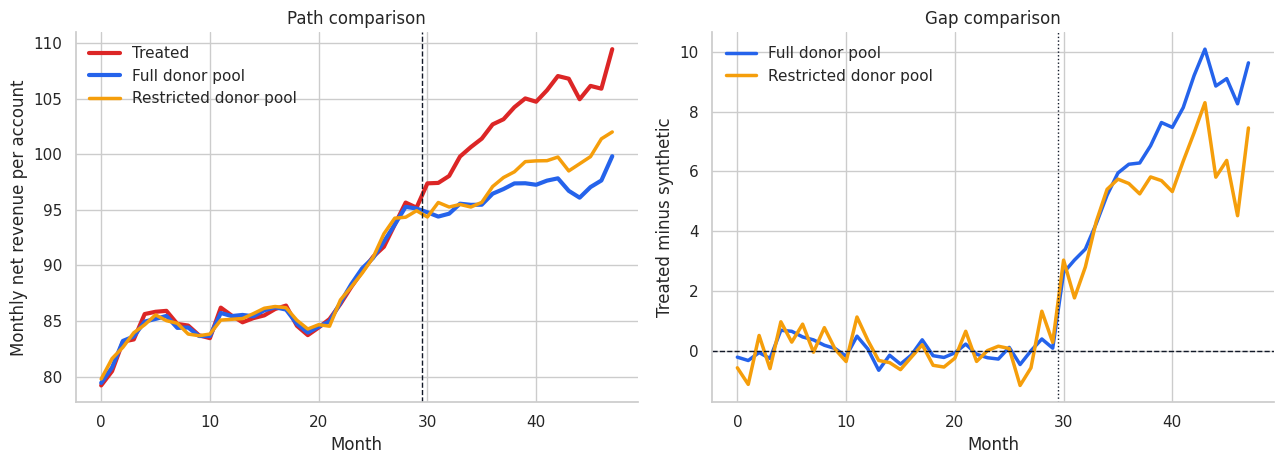

In [21]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

axes[0].plot(synth_path["month"], synth_path["treated"], color="#dc2626", linewidth=3, label="Treated")
axes[0].plot(synth_path["month"], synth_path["synthetic"], color="#2563eb", linewidth=3, label="Full donor pool")
axes[0].plot(restricted_path["month"], restricted_path["synthetic"], color="#f59e0b", linewidth=2.5, label="Restricted donor pool")
axes[0].axvline(intervention_month - 0.5, color="#111827", linestyle="--", linewidth=1)
axes[0].set_title("Path comparison")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Monthly net revenue per account")
axes[0].legend(frameon=False)

axes[1].plot(synth_path["month"], synth_path["gap"], color="#2563eb", linewidth=2.5, label="Full donor pool")
axes[1].plot(restricted_path["month"], restricted_path["gap"], color="#f59e0b", linewidth=2.5, label="Restricted donor pool")
axes[1].axhline(0, color="#111827", linestyle="--", linewidth=1)
axes[1].axvline(intervention_month - 0.5, color="#111827", linestyle=":", linewidth=1)
axes[1].set_title("Gap comparison")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Treated minus synthetic")
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()


The restricted donor pool has worse pre-treatment fit. A post-treatment gap from this restricted design is less credible because the counterfactual was already missing the treated unit before launch. This is why pre-fit is not a cosmetic diagnostic; it is central to the design.


## 10. Augmented Synthetic Control: The Motivation

Sometimes the best convex donor combination still leaves meaningful pre-treatment imbalance. Augmented synthetic control uses an outcome model to estimate and correct bias from imperfect pre-treatment fit. Ben-Michael, Feller, and Rothstein (2021) describe this as a middle ground: keep the transparency of synthetic control but add model-based bias correction when exact balance is not feasible.

The design tradeoff is familiar:

- Constrained synthetic control is transparent and avoids extrapolation, but may fit poorly if the treated unit lies outside the donor convex hull.
- Model-assisted or augmented methods can reduce bias from imperfect fit, but rely more heavily on modeling assumptions.

In an industry report, this should be framed honestly: if the basic synthetic control fits well, use it as the main design. If it fits poorly, consider augmented methods, but do not hide the poor pre-fit.


## 11. Donor Pool Rules

The donor pool is part of the design, not a nuisance parameter. A good donor should be:

- Untreated during the analysis window.
- Exposed to similar macro shocks as the treated unit.
- Not affected by spillovers from the treated intervention.
- Measured consistently with the treated unit.
- Plausibly relevant for the treated unit's untreated path.

A bad donor pool can produce a precise-looking but meaningless synthetic control. Abadie (2021) emphasizes feasibility and data requirements: synthetic control needs enough pre-treatment information and a donor pool capable of approximating the treated unit.


| Rule | Question to ask |
|---|---|
| No treatment contamination | Did any donor receive the policy or a close substitute? |
| No spillovers | Could treated-market launch change donor outcomes? |
| Comparable measurement | Are outcome definitions and data pipelines identical? |
| Common shocks | Do donors face the same demand, seasonality, and macro conditions? |
| Adequate pre-period | Are there enough pre-intervention periods to evaluate fit? |
| Good pre-fit | Does the synthetic unit track the treated unit before launch? |


## 12. Industry Readout Template

A synthetic-control readout should make the design visible:

- **Treated unit:** Which market, region, customer, or product line changed?
- **Intervention date:** When did the intervention start operationally?
- **Donor pool:** Which units were eligible and why?
- **Exclusions:** Which units were removed because of spillovers, contamination, or data problems?
- **Weights:** Which donors formed the synthetic control?
- **Pre-fit:** Path plot, gap plot, and pre-treatment RMSE.
- **Effect path:** Treated minus synthetic after the intervention.
- **Placebos:** How unusual is the treated gap relative to donor placebo gaps?
- **Sensitivity:** Leave-one-out checks for high-weight donors.
- **Decision:** What action follows from the effect size and uncertainty?


In [22]:
# Build the summary table used to connect the calculation back to the design question.
readout = pd.DataFrame(
    {
        "Item": [
            "Treated unit",
            "Intervention",
            "Main estimate",
            "Pre-fit",
            "Placebo evidence",
            "High-weight donors",
            "Sensitivity",
            "Decision implication",
        ],
        "Example entry": [
            "Treated Market",
            f"Premium AI-assisted support policy launched at month {intervention_month}",
            f"Average post-launch gap {fit_summary.loc['average_post_gap', 'synthetic_control']:.2f}",
            f"Pre-treatment RMSE {fit_summary.loc['pre_RMSE', 'synthetic_control']:.2f}",
            f"Post/pre RMSE ratio p-value {placebo_p_value:.3f}",
            ", ".join(plot_weights.sort_values("weight", ascending=False)["unit"].head(4).tolist()),
            "Leave-one-out estimates retain a positive post-launch gap",
            "Scale policy if operational audit rules out donor contamination and spillovers",
        ],
    }
)
smart_display(readout)


,Item,Example entry
0,Treated unit,Treated Market
1,Intervention,Premium AI-assisted support policy launched at month 30
2,Main estimate,Average post-launch gap 6.79
3,Pre-fit,Pre-treatment RMSE 0.33
4,Placebo evidence,Post/pre RMSE ratio p-value 0.048
5,High-weight donors,"Donor 03, Donor 14, Donor 07, Donor 18"
6,Sensitivity,Leave-one-out estimates retain a positive post-launch gap
7,Decision implication,Scale policy if operational audit rules out donor contamination and spillovers


## Key Takeaways

- Synthetic control constructs a counterfactual from a weighted average of untreated donor units.
- Weights are chosen using pre-treatment information, not post-treatment outcomes.
- The path plot and pre-treatment RMSE are central diagnostics.
- The gap plot is the estimated treatment-effect path.
- Placebo-in-space tests compare the treated gap with gaps obtained by pretending each donor was treated.
- Leave-one-out checks reveal whether the result depends on one high-weight donor.
- Poor pre-treatment fit weakens the design, even if the post-treatment gap looks large.
- Donor-pool construction is a substantive design choice and should be reported transparently.


## 12. Real-Data Companion: Synthetic Control Rehearsal with Grunfeld Firms

Synthetic control is often taught with a clean intervention. Real donor pools are less cooperative. The Grunfeld panel lets us rehearse synthetic-control mechanics on real firm investment paths while being honest that we are not evaluating an actual intervention.

We treat General Motors as the focal unit and use other firms as donors. The post boundary is artificial. The exercise is about donor fit, weight concentration, and placebo-style skepticism, not about a real policy effect.

Data source: [statsmodels Grunfeld dataset](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html).

**How to read this real-data section.** The purpose here is to practice the workflow on messy data. The estimate is causal only when the design supplies credible assignment, timing, exposure, comparison groups, and assumptions.


**Real-data dataset note.** The Grunfeld companion treats one firm as a focal unit and the remaining firms as donors. Investment is the outcome, and the post boundary is artificial. This is useful for practicing donor selection, weight concentration, pre-fit assessment, and gap plotting on real panel trajectories. It is not evidence of an intervention effect. The main teaching value is that real donor pools can be lumpy, dominated by one donor, or unable to reproduce the treated path, which should make analysts more cautious than a clean simulation does.

,quantity,value
0,Pre-boundary RMSE,140.063000
1,Post-boundary average gap,325.464000
2,Donors with weight above 0.05,1.000000


,unit,weight
7,US Steel,1.000
2,Chrysler,0.000
5,Goodyear,0.000
8,Union Oil,0.000
4,General Electric,0.000
1,Atlantic Refining,0.000
0,American Steel,0.000
3,Diamond Match,0.000


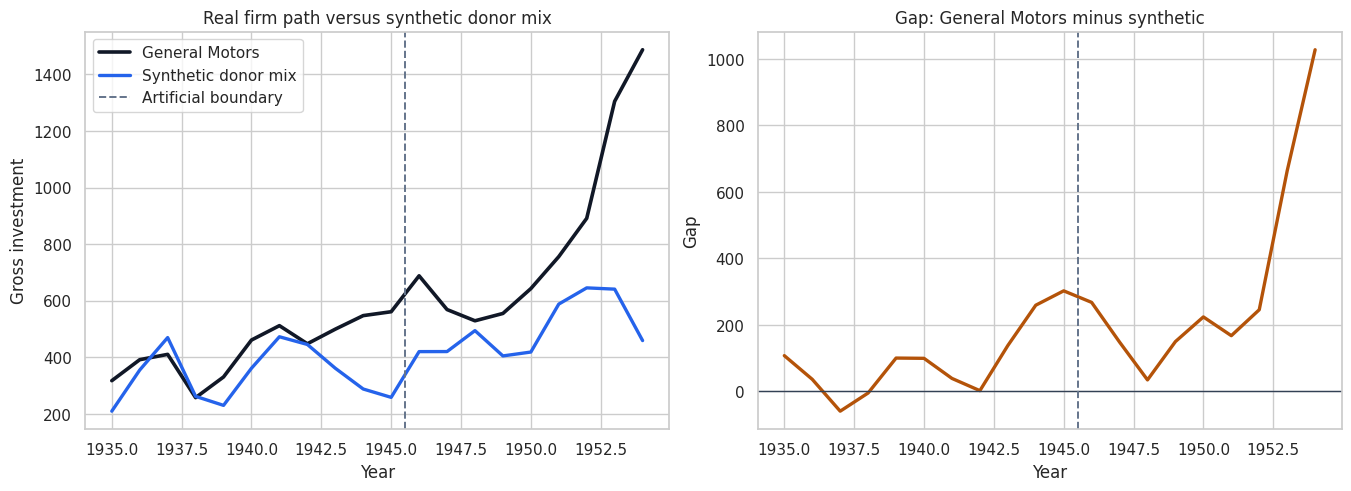

In [23]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_statsmodels_grunfeld, optional_data_note

RUN_REAL_DATA_COMPANION = True
GRUNFELD_SOURCE = "https://www.statsmodels.org/stable/datasets/generated/grunfeld.html"

if RUN_REAL_DATA_COMPANION:
    grunfeld = load_statsmodels_grunfeld().copy()
    grunfeld["year"] = grunfeld["year"].astype(int)
    grunfeld_sc = grunfeld.rename(columns={"firm": "unit", "year": "month", "invest": "outcome"})[
        ["unit", "month", "outcome"]
    ].copy()
    treated_firm = "General Motors"
    intervention_year = 1946
    donor_firms = sorted([firm for firm in grunfeld_sc["unit"].unique() if firm != treated_firm])

    real_weights, real_path, real_result = fit_synthetic_control(
        grunfeld_sc,
        treated_unit=treated_firm,
        donor_units=donor_firms,
        intervention_month=intervention_year,
    )

    real_fit_summary = pd.DataFrame(
        [
            {
                "quantity": "Pre-boundary RMSE",
                "value": np.sqrt(np.mean(real_path.loc[real_path["month"] < intervention_year, "gap"] ** 2)),
            },
            {
                "quantity": "Post-boundary average gap",
                "value": real_path.loc[real_path["month"] >= intervention_year, "gap"].mean(),
            },
            {
                "quantity": "Donors with weight above 0.05",
                "value": int((real_weights["weight"] > 0.05).sum()),
            },
        ]
    )
    smart_display(real_fit_summary.round(3))
    smart_display(real_weights.head(8).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), constrained_layout=True)
    axes[0].plot(real_path["month"], real_path["treated"], color="#111827", linewidth=2.6, label=treated_firm)
    axes[0].plot(real_path["month"], real_path["synthetic"], color="#2563eb", linewidth=2.4, label="Synthetic donor mix")
    axes[0].axvline(intervention_year - 0.5, color="#64748b", linestyle="--", linewidth=1.4, label="Artificial boundary")
    axes[0].set_title("Real firm path versus synthetic donor mix")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Gross investment")
    axes[0].legend()

    axes[1].plot(real_path["month"], real_path["gap"], color="#b45309", linewidth=2.4)
    axes[1].axhline(0, color="#334155", linewidth=1)
    axes[1].axvline(intervention_year - 0.5, color="#64748b", linestyle="--", linewidth=1.4)
    axes[1].set_title("Gap: General Motors minus synthetic")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Gap")
    plt.show()
else:
    optional_data_note("Grunfeld firm investment panel", GRUNFELD_SOURCE, "RUN_REAL_DATA_COMPANION")

The real-data rehearsal highlights a central synthetic-control discipline: fit quality is part of the evidence. A convincing post-period gap is weak if the pre-period synthetic path cannot track the treated unit.

Because the boundary is artificial, the gap is not a causal effect. It is a reminder that the synthetic-control workflow should make donor weights, pre-fit, post-gap behavior, and design credibility visible together.

## References

Abadie, A. (2021). Using synthetic controls: Feasibility, data requirements, and methodological aspects. *Journal of Economic Literature, 59*(2), 391-425. [https://doi.org/10.1257/jel.20191450](https://doi.org/10.1257/jel.20191450)

Abadie, A., Diamond, A., & Hainmueller, J. (2010). Synthetic control methods for comparative case studies: Estimating the effect of California's tobacco control program. *Journal of the American Statistical Association, 105*(490), 493-505. [https://doi.org/10.1198/jasa.2009.ap08746](https://doi.org/10.1198/jasa.2009.ap08746)

Abadie, A., Diamond, A., & Hainmueller, J. (2011). Synth: An R package for synthetic control methods in comparative case studies. *Journal of Statistical Software, 42*(13), 1-17. [https://doi.org/10.18637/jss.v042.i13](https://doi.org/10.18637/jss.v042.i13)

Abadie, A., & Gardeazabal, J. (2003). The economic costs of conflict: A case study of the Basque Country. *American Economic Review, 93*(1), 113-132. [https://doi.org/10.1257/000282803321455188](https://doi.org/10.1257/000282803321455188)

Ben-Michael, E., Feller, A., & Rothstein, J. (2021). The augmented synthetic control method. *Journal of the American Statistical Association, 116*(536), 1789-1803. [https://doi.org/10.1080/01621459.2021.1929245](https://doi.org/10.1080/01621459.2021.1929245)
